In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, HTML

In [2]:
#Importing Excel sheet data and defining column headers
df = pd.read_excel('Directed Study Data-CamiloDeCalisto.xlsx', na_values=['Na'])
df.columns = ['Source','SampleID','Location','Formation','Time_Period','Min_Age','Max_Age','Depth','Sample_Type','Lithology','Mineralogy','Delta_Ca','Ca_Ratio','Standard','Sr','Sr_Unit','Sr/Ca','Sr/Ca_Unit','Delta_Ca_SW', 'Sr/Ca_mmol/mol']
#Creating new Median age column to act as x values for plotting
df.insert(6, 'Med_Age', (df['Max_Age'] + df['Min_Age'])/2)

In [3]:
#Creating lowess best fit line
x = df['Med_Age']
y = df['Delta_Ca_SW']
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

smoothed = lowess(y, x, frac=0.2)

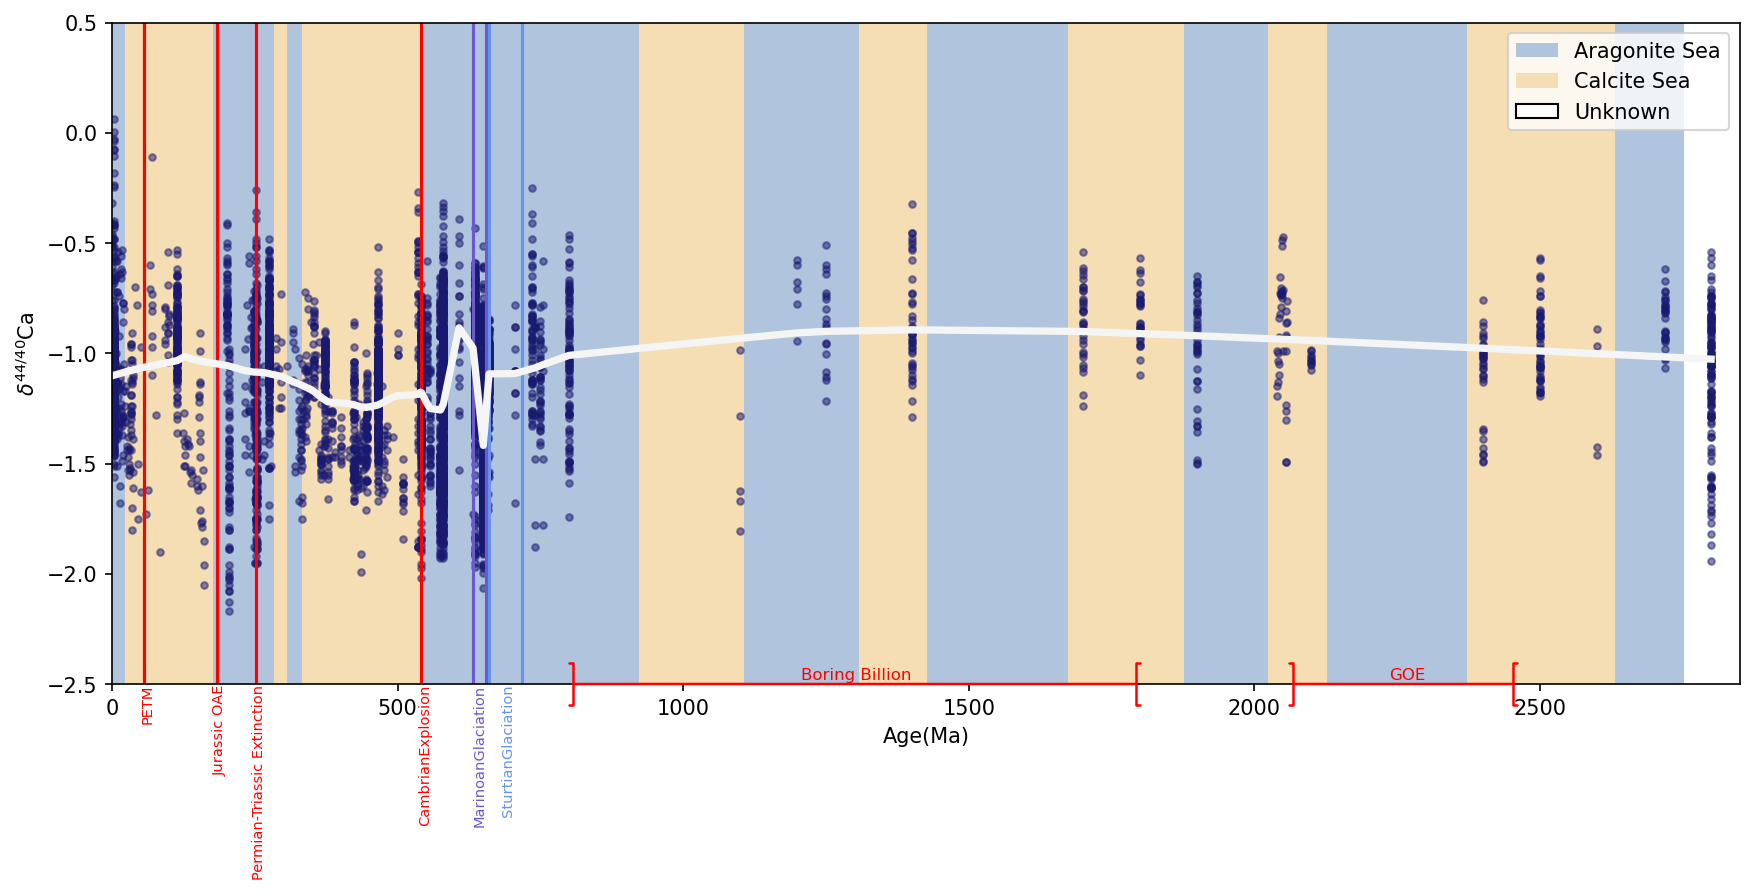

In [12]:
fig, ax=plt.subplots(figsize=(14, 7), dpi=150) 
ax.scatter(df['Med_Age'], df['Delta_Ca_SW'], color='midnightblue', s=10, alpha=0.5)
plt.subplots_adjust(bottom=0.25)

ax.set_xlabel('Age(Ma)')
ax.set_ylabel(r'$\delta^{44/40}$Ca')
plt.ylim(-2.5, 0.5)
plt.xlim(0, 2850)

#Plotting lines to represent the start and end of the Sturtian Glaciation (660Ma - 717Ma)
plt.axvline(x=717, color='cornflowerblue', label='Sturtian Glaciation Start')
plt.axvline(x=660, color='cornflowerblue', label='Sturtian Glaciation End')
ax.text(705, 0, 'SturtianGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='cornflowerblue')

#Plotting lines to represent the start and end of the Marinoan Glaciation (632.3Ma - 654.5Ma)
plt.axvline(x=654.5, color='slateblue', label='Marinoan Glaciation Start')
plt.axvline(x=632.3, color='slateblue', label='Marinoan Glaciation End')
ax.text(655, 0, 'MarinoanGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='slateblue')

#Plotting line representing the Cambrian Explosion (541Ma)
plt.axvline(x=541, color='r', label='Cambrian Explosion')
ax.text(560, 0, 'CambrianExplosion',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Jurassic Ocean Acidification Event (183Ma)
plt.axvline(x=183, color='r', label='Jurassic OAE')
ax.text(200, 0, 'Jurassic OAE',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Paleocene-Eocene Thermal Maximum (56Ma)
plt.axvline(x=56, color='r', label='PETM')
ax.text(75, 0, 'PETM',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Permian-Triassic Mass Extinction (251.9Ma)
plt.axvline(x=251.9, color='r', label='PETM')
ax.text(270, 0, 'Permian-Triassic Extinction',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Range representing the Boring Billion Time Period (800Ma - 1800Ma)
ax.annotate('', xy=(1800, 0), xytext=(800, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(1400, .025, 'Boring Billion',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Range representing the Great Oxidation Event Time Period (2060Ma - 2460Ma)
ax.annotate('', xy=(2460, 0), xytext=(2060, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(2300, .025, 'GOE',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Background shading for Aragonite Sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(0, 25, color='lightsteelblue', zorder=0)
plt.axvspan(175, 285, color='lightsteelblue', zorder=0)
plt.axvspan(305, 335, color='lightsteelblue', zorder=0)
plt.axvspan(545, 925, color='lightsteelblue', zorder=0)
plt.axvspan(1105, 1310, color='lightsteelblue', zorder=0)
plt.axvspan(1425, 1675, color='lightsteelblue', zorder=0)
plt.axvspan(1875, 2025, color='lightsteelblue', zorder=0)
plt.axvspan(2125, 2375, color='lightsteelblue', zorder=0)
plt.axvspan(2630, 2750, color='lightsteelblue', zorder=0)

#Background shading for Calcite sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(925, 1105, color='wheat', zorder=0)
plt.axvspan(1310, 1425, color='wheat', zorder=0)
plt.axvspan(25, 175, color='wheat', zorder=0)
plt.axvspan(285, 305, color='wheat', zorder=0)
plt.axvspan(335, 545, color='wheat', zorder=0)
plt.axvspan(1675, 1875, color='wheat', zorder=0)
plt.axvspan(2025, 2125, color='wheat', zorder=0)
plt.axvspan(2375, 2630, color='wheat', zorder=0)

#Legend entries for aragonite and calcite sea time periods
legend_handles = [Patch(facecolor='lightsteelblue', label='Aragonite Sea', alpha=1.0), Patch(facecolor='wheat', label='Calcite Sea', alpha=1.0), Patch(facecolor='white', label="Unknown", alpha=1.0, edgecolor='black')]
plt.legend(handles=legend_handles)

#Plotting Lowess best fit line
plt.plot(smoothed[:, 0], smoothed[:, 1], color='whitesmoke', label='LOWESS fit', linewidth=3.5)

plt.savefig("DirectedStudyData.png")

In [5]:
AragoniteSeaAges = [(0, 25), (175, 285), (305, 335), (545, 925), (1105, 1310), (1425, 1675), (1875, 2025), (2125, 2375), (2630, 2750)]
mask_Arag = False
for start, end in AragoniteSeaAges:
    mask_Arag |= (df['Med_Age'].between(start, end))

df_Aragonite = df[mask_Arag]


CalciteSeaAges = [(25, 175), (285, 305), (335, 545), (925, 1105), (1310, 1425), (1675, 1875), (2025, 2125), (2375, 2630)]
mask_Calc = False
for start, end in CalciteSeaAges:
    mask_Calc |= (df['Med_Age'].between(start, end))

df_Calcite = df[mask_Calc]

#Statistical analysis of Aragonite Sea periods
Mean_Arag = df_Aragonite['Delta_Ca_SW'].mean()
Std_Arag = np.std(df_Aragonite['Delta_Ca_SW'], ddof = 1)
cv_Arag = (Std_Arag / abs(Mean_Arag))

#Statistical analysis of Calcite Sea periods
Mean_Calc = df_Calcite['Delta_Ca_SW'].mean()
Std_Calc = np.std(df_Calcite['Delta_Ca_SW'], ddof = 1)
cv_Calc = (Std_Calc / abs(Mean_Arag))

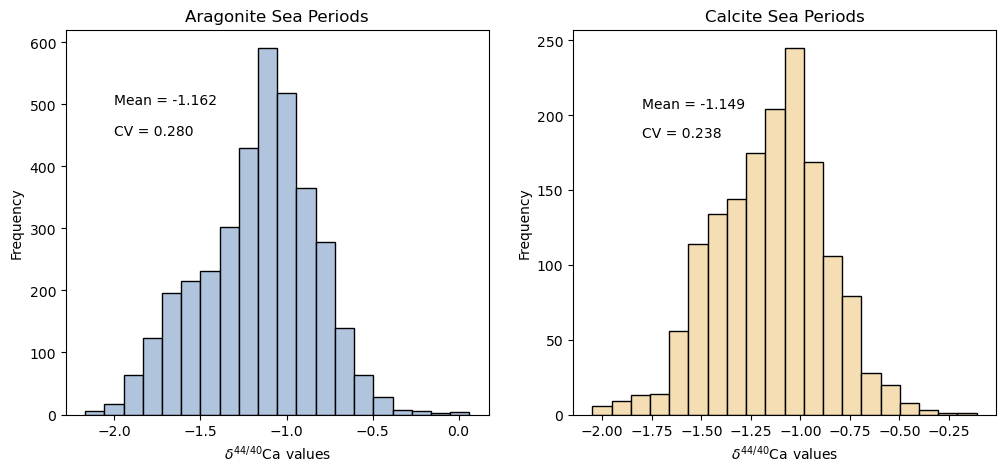

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_Aragonite['Delta_Ca_SW'], bins=20, color='lightsteelblue', edgecolor='black')
axes[0].set_title('Aragonite Sea Periods')
axes[0].set_xlabel('$\delta^{44/40}$Ca$_{}$ values')
axes[0].set_ylabel('Frequency')
axes[0].text(x = -2, y = 500, s=f"Mean = {Mean_Arag:.3f}")
axes[0].text(x = -2, y = 450, s=f"CV = {cv_Arag:.3f}")

axes[1].hist(df_Calcite['Delta_Ca_SW'], bins=20, color='wheat', edgecolor='black')
axes[1].set_title('Calcite Sea Periods')
axes[1].set_xlabel('$\delta^{44/40}$Ca$_{}$ values')
axes[1].set_ylabel('Frequency')
axes[1].text(x = -1.80, y = 205, s=f"Mean = {Mean_Calc:.3f}")
axes[1].text(x = -1.80, y = 185, s=f"CV = {cv_Calc:.3f}")

plt.savefig('Aragonite_Calcite_Histograms.png')

In [7]:
#Creating lowess best fit line
x = df['Med_Age']
y = df['Sr/Ca_mmol/mol']
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

smoothed2 = lowess(y, x, frac=0.2)

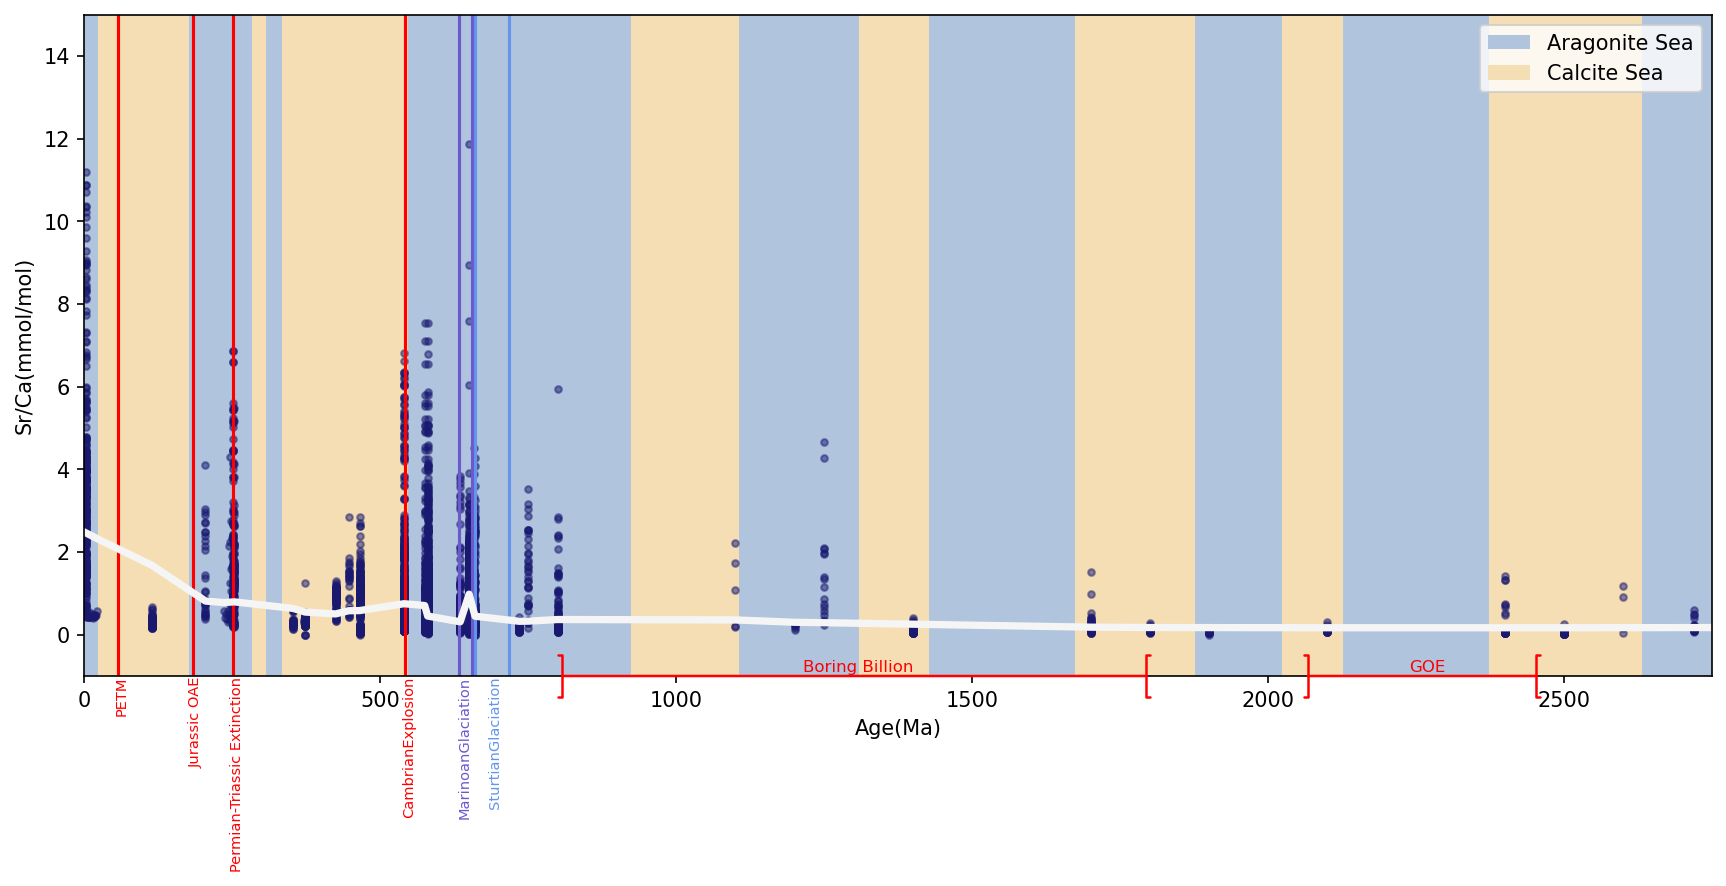

In [8]:
fig, ax=plt.subplots(figsize=(14, 7), dpi=150) 
ax.scatter(df['Med_Age'], df['Sr/Ca_mmol/mol'], color='midnightblue', s=10, alpha=0.5)
plt.subplots_adjust(bottom=0.25)

ax.set_xlabel('Age(Ma)')
ax.set_ylabel('Sr/Ca(mmol/mol)')
plt.ylim(-1, 15)
plt.xlim(0, 2750)

#Plotting lines to represent the start and end of the Sturtian Glaciation (660Ma - 717Ma)
plt.axvline(x=717, color='cornflowerblue', label='Sturtian Glaciation Start')
plt.axvline(x=660, color='cornflowerblue', label='Sturtian Glaciation End')
ax.text(705, 0, 'SturtianGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='cornflowerblue')

#Plotting lines to represent the start and end of the Marinoan Glaciation (632.3Ma - 654.5Ma)
plt.axvline(x=654.5, color='slateblue', label='Marinoan Glaciation Start')
plt.axvline(x=632.3, color='slateblue', label='Marinoan Glaciation End')
ax.text(655, 0, 'MarinoanGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='slateblue')

#Plotting line representing the Cambrian Explosion (541Ma)
plt.axvline(x=541, color='r', label='Cambrian Explosion')
ax.text(560, 0, 'CambrianExplosion',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Jurassic Ocean Acidification Event (183Ma)
plt.axvline(x=183, color='r', label='Jurassic OAE')
ax.text(200, 0, 'Jurassic OAE',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Paleocene-Eocene Thermal Maximum (56Ma)
plt.axvline(x=56, color='r', label='PETM')
ax.text(75, 0, 'PETM',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Permian-Triassic Mass Extinction (251.9Ma)
plt.axvline(x=251.9, color='r', label='PETM')
ax.text(270, 0, 'Permian-Triassic Extinction',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Range representing the Boring Billion Time Period (800Ma - 1800Ma)
ax.annotate('', xy=(1800, 0), xytext=(800, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(1400, .025, 'Boring Billion',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Range representing the Great Oxidation Event Time Period (2060Ma - 2460Ma)
ax.annotate('', xy=(2460, 0), xytext=(2060, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(2300, .025, 'GOE',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Background shading for Aragonite Sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(0, 25, color='lightsteelblue', zorder=0)
plt.axvspan(175, 285, color='lightsteelblue', zorder=0)
plt.axvspan(305, 335, color='lightsteelblue', zorder=0)
plt.axvspan(545, 925, color='lightsteelblue', zorder=0)
plt.axvspan(1105, 1310, color='lightsteelblue', zorder=0)
plt.axvspan(1425, 1675, color='lightsteelblue', zorder=0)
plt.axvspan(1875, 2025, color='lightsteelblue', zorder=0)
plt.axvspan(2125, 2375, color='lightsteelblue', zorder=0)
plt.axvspan(2630, 2750, color='lightsteelblue', zorder=0)

#Background shading for Calcite sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(925, 1105, color='wheat', zorder=0)
plt.axvspan(1310, 1425, color='wheat', zorder=0)
plt.axvspan(25, 175, color='wheat', zorder=0)
plt.axvspan(285, 305, color='wheat', zorder=0)
plt.axvspan(335, 545, color='wheat', zorder=0)
plt.axvspan(1675, 1875, color='wheat', zorder=0)
plt.axvspan(2025, 2125, color='wheat', zorder=0)
plt.axvspan(2375, 2630, color='wheat', zorder=0)

#Legend entries for aragonite and calcite sea time periods
legend_handles = [Patch(facecolor='lightsteelblue', label='Aragonite Sea', alpha=1.0), Patch(facecolor='wheat', label='Calcite Sea', alpha=1.0)]
plt.legend(handles=legend_handles)

#Plotting Lowess best fit line
plt.plot(smoothed2[:, 0], smoothed2[:, 1], color='whitesmoke', label='LOWESS fit', linewidth=3.5)

plt.savefig('Sr_Ca_Plot.png')

In [9]:
#Statistical analysis of Aragonite Sea periods
Mean1_Arag = df_Aragonite['Sr/Ca_mmol/mol'].mean()
Std1_Arag = np.std(df_Aragonite['Sr/Ca_mmol/mol'], ddof = 1)
cv1_Arag = (Std1_Arag / abs(Mean1_Arag))

#Statistical analysis of Calcite Sea periods
Mean1_Calc = df_Calcite['Sr/Ca_mmol/mol'].mean()
Std1_Calc = np.std(df_Calcite['Sr/Ca_mmol/mol'], ddof = 1)
cv1_Calc = (Std1_Calc / abs(Mean1_Arag))

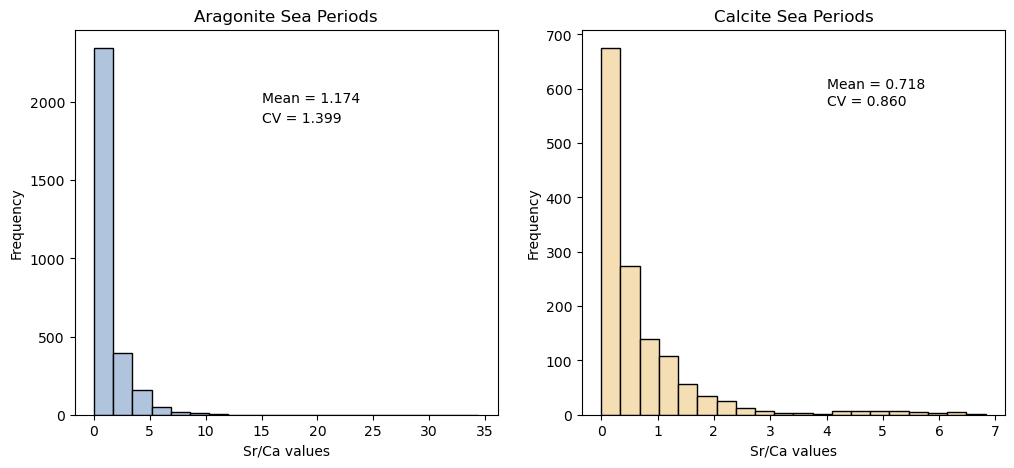

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_Aragonite['Sr/Ca_mmol/mol'], bins=20, color='lightsteelblue', edgecolor='black')
axes[0].set_title('Aragonite Sea Periods')
axes[0].set_xlabel('Sr/Ca values')
axes[0].set_ylabel('Frequency')
axes[0].text(x = 15, y = 2000, s=f"Mean = {Mean1_Arag:.3f}")
axes[0].text(x = 15, y = 1870, s=f"CV = {cv1_Arag:.3f}")

axes[1].hist(df_Calcite['Sr/Ca_mmol/mol'], bins=20, color='wheat', edgecolor='black')
axes[1].set_title('Calcite Sea Periods')
axes[1].set_xlabel('Sr/Ca values')
axes[1].set_ylabel('Frequency')
axes[1].text(x = 4, y = 600, s=f"Mean = {Mean1_Calc:.3f}")
axes[1].text(x = 4, y = 570, s=f"CV = {cv1_Calc:.3f}")

plt.savefig('Sr_Ca_Histograms.png')

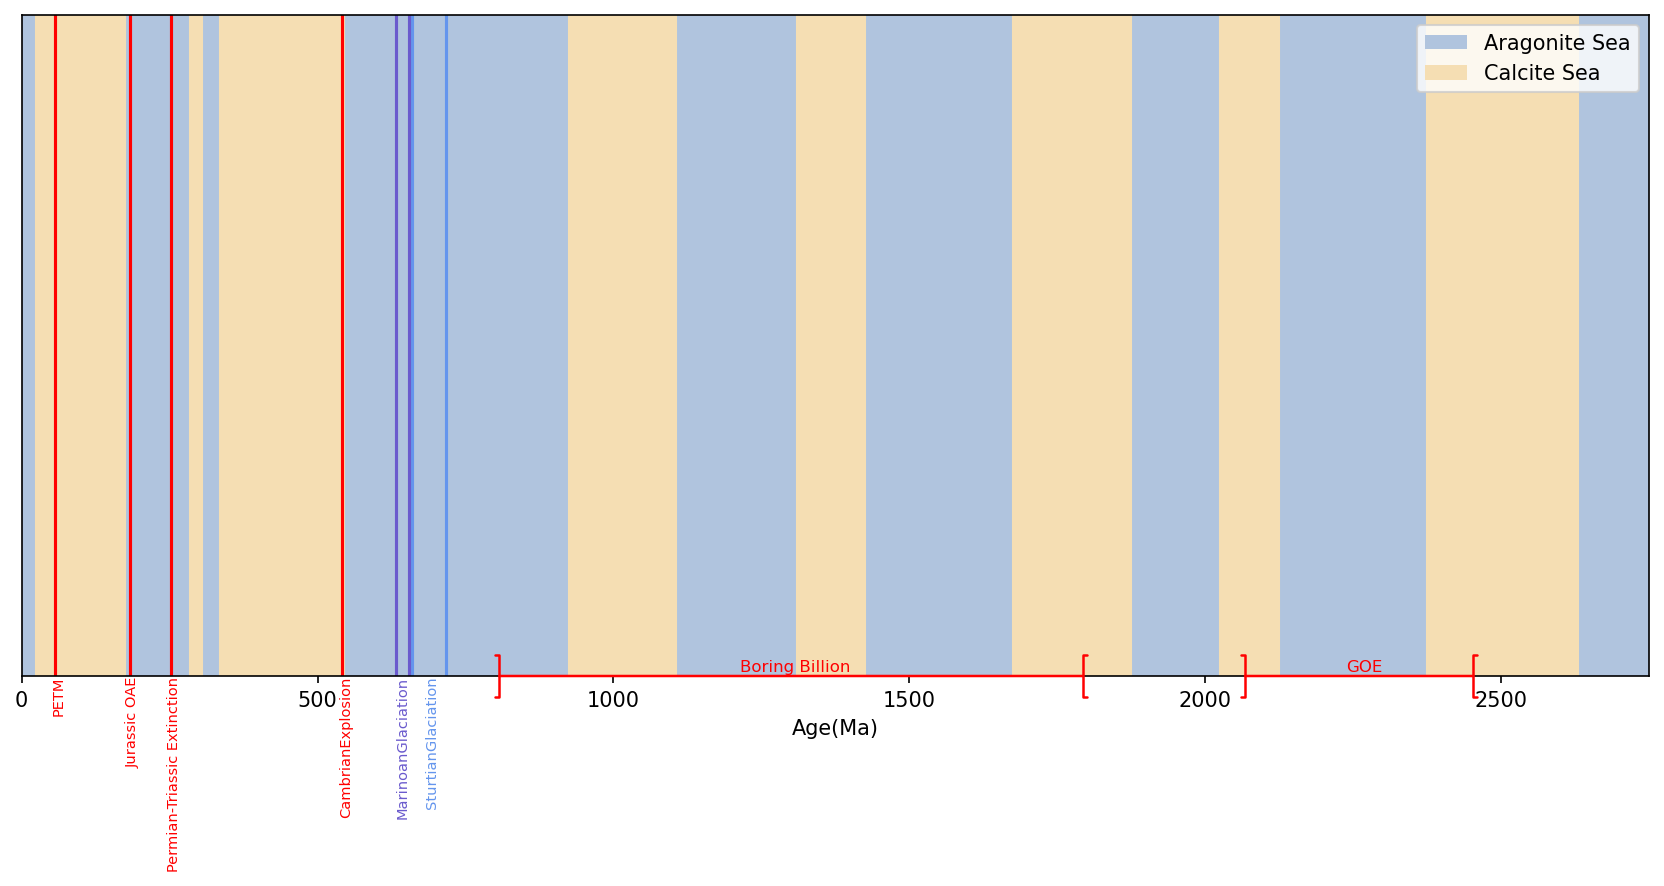

In [11]:
fig, ax=plt.subplots(figsize=(14, 7), dpi=150) 
ax.scatter(df['Med_Age'], np.zeros_like(df['Med_Age']), color='midnightblue', s=0, alpha=0.5)
plt.subplots_adjust(bottom=0.25)
ax.get_yaxis().set_visible(False)

ax.set_xlabel('Age(Ma)')
ax.set_ylabel(r'$\delta^{44/40}$Ca')
plt.ylim(-2.5, 0.5)
plt.xlim(0, 2750)

#Plotting lines to represent the start and end of the Sturtian Glaciation (660Ma - 717Ma)
plt.axvline(x=717, color='cornflowerblue', label='Sturtian Glaciation Start')
plt.axvline(x=660, color='cornflowerblue', label='Sturtian Glaciation End')
ax.text(705, 0, 'SturtianGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='cornflowerblue')

#Plotting lines to represent the start and end of the Marinoan Glaciation (632.3Ma - 654.5Ma)
plt.axvline(x=654.5, color='slateblue', label='Marinoan Glaciation Start')
plt.axvline(x=632.3, color='slateblue', label='Marinoan Glaciation End')
ax.text(655, 0, 'MarinoanGlaciation',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='slateblue')

#Plotting line representing the Cambrian Explosion (541Ma)
plt.axvline(x=541, color='r', label='Cambrian Explosion')
ax.text(560, 0, 'CambrianExplosion',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Jurassic Ocean Acidification Event (183Ma)
plt.axvline(x=183, color='r', label='Jurassic OAE')
ax.text(200, 0, 'Jurassic OAE',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Paleocene-Eocene Thermal Maximum (56Ma)
plt.axvline(x=56, color='r', label='PETM')
ax.text(75, 0, 'PETM',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Plotting line representing the Permian-Triassic Mass Extinction (251.9Ma)
plt.axvline(x=251.9, color='r', label='PETM')
ax.text(270, 0, 'Permian-Triassic Extinction',rotation=90,va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=7, color='r')

#Range representing the Boring Billion Time Period (800Ma - 1800Ma)
ax.annotate('', xy=(1800, 0), xytext=(800, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(1400, .025, 'Boring Billion',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Range representing the Great Oxidation Event Time Period (2060Ma - 2460Ma)
ax.annotate('', xy=(2460, 0), xytext=(2060, 0), xycoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle=']-[', lw=1.2, color='r'))
ax.text(2300, .025, 'GOE',va='top', ha='right',transform=ax.get_xaxis_transform(),fontsize=8, color='r')

#Background shading for Aragonite Sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(0, 25, color='lightsteelblue', zorder=0)
plt.axvspan(175, 285, color='lightsteelblue', zorder=0)
plt.axvspan(305, 335, color='lightsteelblue', zorder=0)
plt.axvspan(545, 925, color='lightsteelblue', zorder=0)
plt.axvspan(1105, 1310, color='lightsteelblue', zorder=0)
plt.axvspan(1425, 1675, color='lightsteelblue', zorder=0)
plt.axvspan(1875, 2025, color='lightsteelblue', zorder=0)
plt.axvspan(2125, 2375, color='lightsteelblue', zorder=0)
plt.axvspan(2630, 2750, color='lightsteelblue', zorder=0)

#Background shading for Calcite sea periods based on Hardie (1996) and Ries (2008)
plt.axvspan(925, 1105, color='wheat', zorder=0)
plt.axvspan(1310, 1425, color='wheat', zorder=0)
plt.axvspan(25, 175, color='wheat', zorder=0)
plt.axvspan(285, 305, color='wheat', zorder=0)
plt.axvspan(335, 545, color='wheat', zorder=0)
plt.axvspan(1675, 1875, color='wheat', zorder=0)
plt.axvspan(2025, 2125, color='wheat', zorder=0)
plt.axvspan(2375, 2630, color='wheat', zorder=0)

#Legend entries for aragonite and calcite sea time periods
legend_handles = [Patch(facecolor='lightsteelblue', label='Aragonite Sea', alpha=1.0), Patch(facecolor='wheat', label='Calcite Sea', alpha=1.0)]
plt.legend(handles=legend_handles)

#Plotting Lowess best fit line
# plt.plot(smoothed[:, 0], smoothed[:, 1], color='whitesmoke', label='LOWESS fit', linewidth=3.5)

plt.savefig("CalciteSeasPlot.png")